# Datathon 2026 — EDA: Phần 2 (Trực quan hoá & Phân tích EDA)

Notebook này chuẩn bị dữ liệu một lần, sau đó phân tích ba insight chính của Phần 2:

1. **Lệch cơ cấu sản phẩm theo vùng làm giảm giá trị đơn hàng** — vùng Tây có AOV thấp hơn ~14% do cơ cấu danh mục, không phải pricing.
2. **Khuyến mãi đang đổi lợi nhuận lấy doanh thu** — promo tạo 29.9% revenue nhưng lỗ gross ~₫677M.
3. **Doanh thu mùa cao điểm bị chặn bởi năng lực tồn kho** — peak Apr–Jun đi kèm stockout cao, fill_rate giảm.

Mỗi insight được trình bày theo cấu trúc: Giả thuyết → Bằng chứng (biểu đồ) → Kết luận → Hàm ý kinh doanh → Hành động đề xuất.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None
    plt.style.use("seaborn-v0_8-whitegrid")

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_DIR = Path("data")
PLOT_SIZE = (12, 5)

def finish_plot(title, xlabel=None, ylabel=None, legend=True, rotation=0):
    # A consistent plot helper keeps every chart readable and presentation-friendly.
    plt.title(title, fontsize=14, weight="bold")
    if xlabel is not None:
        plt.xlabel(xlabel)
    if ylabel is not None:
        plt.ylabel(ylabel)
    if rotation:
        plt.xticks(rotation=rotation, ha="right")
    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        if handles:
            plt.legend(frameon=False)
    else:
        leg = plt.gca().get_legend()
        if leg is not None:
            leg.remove()
    plt.tight_layout()
    plt.show()

def summarize_missing(df, table_name):
    # Missingness is reported before business-specific handling so assumptions stay visible.
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if missing.empty:
        print(f"{table_name}: no missing values detected.")
    else:
        print(f"{table_name}: missing values")
        display(pd.DataFrame({"missing_count": missing, "missing_pct": missing / len(df)}))

## 0. Data Loading

We load every provided CSV into a dictionary and expose each table as a named DataFrame. This keeps the notebook explicit and prevents accidentally skipping a required dataset.

In [2]:
files = {
    "products": "products.csv",
    "customers": "customers.csv",
    "promotions": "promotions.csv",
    "geography": "geography.csv",
    "orders": "orders.csv",
    "order_items": "order_items.csv",
    "payments": "payments.csv",
    "shipments": "shipments.csv",
    "returns": "returns.csv",
    "reviews": "reviews.csv",
    "sales": "sales.csv",
    "inventory": "inventory.csv",
    "web_traffic": "web_traffic.csv",
}

missing_files = [name for name, file in files.items() if not (DATA_DIR / file).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing required CSV files: {missing_files}")

data = {name: pd.read_csv(DATA_DIR / file) for name, file in files.items()}

products = data["products"].copy()
customers = data["customers"].copy()
promotions = data["promotions"].copy()
geography = data["geography"].copy()
orders = data["orders"].copy()
order_items = data["order_items"].copy()
payments = data["payments"].copy()
shipments = data["shipments"].copy()
returns = data["returns"].copy()
reviews = data["reviews"].copy()
sales = data["sales"].copy()
inventory = data["inventory"].copy()
web_traffic = data["web_traffic"].copy()

summary = pd.DataFrame({
    "table": list(data.keys()),
    "rows": [len(df) for df in data.values()],
    "columns": [df.shape[1] for df in data.values()],
})
display(summary)

,table,rows,columns
0,products,2412,8
1,customers,121930,7
2,promotions,50,10
3,geography,39948,4
4,orders,646945,8
5,order_items,714669,7
6,payments,646945,4
7,shipments,566067,4
8,returns,39939,7
9,reviews,113551,7


In [3]:
for name, df in data.items():
    print(f"\n{name.upper()} - shape={df.shape}")
    display(df.head(3))


PRODUCTS - shape=(2412, 8)


,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,"11,059.65","9,704.84"
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,"9,523.08","5,393.87"
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,"15,951.63","11,371.92"



CUSTOMERS - shape=(121930, 7)


,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search



PROMOTIONS - shape=(50, 10)


...

,Date,Revenue,COGS
0,2012-07-04,"5,123,547.94","3,982,991.19"
1,2012-07-05,"2,751,773.45","2,150,580.23"
2,2012-07-06,"3,054,029.42","2,517,632.84"



INVENTORY - shape=(60247, 17)


,snapshot_date,product_id,stock_on_hand,units_received,units_sold,stockout_days,days_of_supply,fill_rate,stockout_flag,overstock_flag,reorder_flag,sell_through_rate,product_name,category,segment,year,month
0,2022-10-31,1,3,1,1,2,90.00,0.93,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,10
1,2022-11-30,1,3,1,1,1,90.00,0.97,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,11
2,2022-12-31,1,3,1,1,1,90.00,0.97,1,0,0,0.25,DragonWear MA-01,Casual,All-weather,2022,12



WEB_TRAFFIC - shape=(3652, 7)


,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
0,2013-01-01,9760,7253,39093,0.01,102.90,organic_search
1,2013-01-02,10456,8151,47611,0.00,120.50,organic_search
2,2013-01-03,10076,7458,36963,0.00,263.60,direct


# Step 1 - Data Cleaning

The goal is not to delete imperfect records blindly. Instead, we standardize types, resolve invalid duplicates, create business flags for missing relationships, and surface quality issues that may affect interpretation.

## 1.1 Data Types

Date columns are converted to datetime so we can aggregate by day, month, and period correctly. Numeric columns are converted using safe coercion so invalid values become `NaN` and can be inspected.

In [4]:
date_columns = {
    "customers": ["signup_date"],
    "promotions": ["start_date", "end_date"],
    "orders": ["order_date"],
    "shipments": ["ship_date", "delivery_date"],
    "returns": ["return_date"],
    "reviews": ["review_date"],
    "sales": ["Date"],
    "inventory": ["snapshot_date"],
    "web_traffic": ["date"],
}

for table_name, cols in date_columns.items():
    df = globals()[table_name]
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

numeric_columns = {
    "products": ["product_id", "price", "cogs"],
    "customers": ["customer_id", "zip"],
    "geography": ["zip"],
    "orders": ["order_id", "customer_id", "zip"],
    "order_items": ["order_id", "product_id", "quantity", "unit_price", "discount_amount"],
    "payments": ["order_id", "payment_value", "installments"],
    "shipments": ["order_id", "shipping_fee"],
    "returns": ["order_id", "product_id", "return_quantity", "refund_amount"],
    "reviews": ["order_id", "product_id", "customer_id", "rating"],
    "sales": ["Revenue", "COGS"],
    "inventory": ["product_id", "stock_on_hand", "units_received", "units_sold", "stockout_days", "days_of_supply", "fill_rate", "stockout_flag", "overstock_flag", "reorder_flag", "sell_through_rate", "year", "month"],
    "web_traffic": ["sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec"],
}

for table_name, cols in numeric_columns.items():
    df = globals()[table_name]
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

sales = sales.rename(columns={"Date": "date", "Revenue": "revenue", "COGS": "cogs"})
print("Data type conversion complete.")

Data type conversion complete.


## 1.2 Duplicates and Primary Keys

Primary keys should uniquely identify master and transaction records. For `order_items`, duplicate `(order_id, product_id)` rows can represent split lines, so we aggregate them instead of dropping them.

In [5]:
primary_keys = {"products": "product_id", "customers": "customer_id", "orders": "order_id"}

for table_name, key in primary_keys.items():
    df = globals()[table_name]
    duplicate_count = df.duplicated(subset=[key]).sum()
    print(f"{table_name}.{key}: {duplicate_count} duplicate key rows")
    if duplicate_count > 0:
        globals()[table_name] = df.drop_duplicates(subset=[key], keep="first").copy()

order_items["has_promo"] = order_items["promo_id"].notna().astype(int)
order_items["line_revenue"] = order_items["quantity"] * order_items["unit_price"] - order_items["discount_amount"].fillna(0)

before_rows = len(order_items)
item_keys = ["order_id", "product_id"]

# Numeric columns use fast vectorized aggregations. Promo IDs are aggregated separately with first(),
# which skips nulls and avoids slow per-group Python lambdas on the full order_items table.
item_numeric = order_items.groupby(item_keys, as_index=False).agg(
    quantity=("quantity", "sum"),
    unit_price=("unit_price", "mean"),
    discount_amount=("discount_amount", "sum"),
    line_revenue=("line_revenue", "sum"),
    has_promo=("has_promo", "max"),
)

promo_cols = [col for col in ["promo_id", "promo_id_2"] if col in order_items.columns]
if promo_cols:
    item_promos = order_items.groupby(item_keys, as_index=False)[promo_cols].first()
    order_items = item_numeric.merge(item_promos, on=item_keys, how="left")
else:
    order_items = item_numeric

after_rows = len(order_items)
print(f"order_items rows before aggregation: {before_rows:,}")
print(f"order_items rows after aggregation:  {after_rows:,}")


products.product_id: 0 duplicate key rows
customers.customer_id: 0 duplicate key rows
orders.order_id: 0 duplicate key rows
order_items rows before aggregation: 714,669
order_items rows after aggregation:  714,653


## 1.3 Missing Values and Business Flags

Missing values have different meanings by table. Customer demographics can be labeled as unknown, while missing shipments, returns, and reviews often mean that an event did not happen or has not happened yet.

In [6]:
for col in ["gender", "age_group", "acquisition_channel"]:
    if col in customers.columns:
        customers[col] = customers[col].fillna("Unknown")

order_items["has_promo"] = order_items["promo_id"].notna().astype(int)

return_flags = (
    returns.assign(has_return=1)
    .groupby(["order_id", "product_id"], as_index=False)
    .agg(
        has_return=("has_return", "max"),
        return_quantity=("return_quantity", "sum"),
        refund_amount=("refund_amount", "sum"),
        return_reason=("return_reason", lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan),
    )
)

review_flags = (
    reviews.assign(has_review=1)
    .groupby(["order_id", "product_id"], as_index=False)
    .agg(has_review=("has_review", "max"), rating=("rating", "mean"), review_date=("review_date", "min"))
)

for name, df in {
    "customers": customers,
    "order_items": order_items,
    "shipments": shipments,
    "returns": returns,
    "reviews": reviews,
    "inventory": inventory,
    "web_traffic": web_traffic,
}.items():
    summarize_missing(df, name)

customers: no missing values detected.
order_items: missing values


,missing_count,missing_pct
promo_id_2,714447,1.00
promo_id,438344,0.61


shipments: no missing values detected.
returns: no missing values detected.
reviews: no missing values detected.
inventory: no missing values detected.
web_traffic: no missing values detected.


In [7]:
inventory_issues = {}
for col in ["stock_on_hand", "units_received", "units_sold", "stockout_days", "days_of_supply"]:
    if col in inventory.columns:
        inventory_issues[f"negative_{col}"] = int((inventory[col] < 0).sum())
for col in ["fill_rate", "sell_through_rate"]:
    if col in inventory.columns:
        inventory_issues[f"invalid_{col}"] = int(((inventory[col] < 0) | (inventory[col] > 1)).sum())

traffic_issues = {}
for col in ["sessions", "unique_visitors", "page_views", "avg_session_duration_sec"]:
    if col in web_traffic.columns:
        traffic_issues[f"negative_{col}"] = int((web_traffic[col] < 0).sum())
for col in ["bounce_rate"]:
    if col in web_traffic.columns:
        traffic_issues[f"invalid_{col}"] = int(((web_traffic[col] < 0) | (web_traffic[col] > 1)).sum())

quality_report = pd.DataFrame([
    {"area": "inventory", **inventory_issues},
    {"area": "web_traffic", **traffic_issues},
]).fillna(0)
display(quality_report)

,area,negative_stock_on_hand,negative_units_received,negative_units_sold,negative_stockout_days,negative_days_of_supply,invalid_fill_rate,invalid_sell_through_rate,negative_sessions,negative_unique_visitors,negative_page_views,negative_avg_session_duration_sec,invalid_bounce_rate
0,inventory,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,web_traffic,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


## 1.4 Consistency Checks

These checks test whether values agree across tables and business rules. They are not automatically deleted because they may reveal operational or data pipeline issues.

In [8]:
product_margin_issues = products.query("cogs >= price") if {"cogs", "price"}.issubset(products.columns) else pd.DataFrame()
print(f"Products with cogs >= price: {len(product_margin_issues):,}")
display(product_margin_issues.head())

shipment_date_issues = shipments.query("ship_date > delivery_date") if {"ship_date", "delivery_date"}.issubset(shipments.columns) else pd.DataFrame()
print(f"Shipments with ship_date > delivery_date: {len(shipment_date_issues):,}")
display(shipment_date_issues.head())

order_item_totals = order_items.groupby("order_id", as_index=False).agg(item_total=("line_revenue", "sum"))
payment_totals = payments.groupby("order_id", as_index=False).agg(payment_total=("payment_value", "sum"))
payment_check = order_item_totals.merge(payment_totals, on="order_id", how="left")
payment_check["difference"] = payment_check["payment_total"] - payment_check["item_total"]
payment_check["abs_difference"] = payment_check["difference"].abs()

print("Payment reconciliation summary:")
display(payment_check["difference"].describe())
display(payment_check.sort_values("abs_difference", ascending=False).head(10))

Products with cogs >= price: 0


,product_id,product_name,category,segment,size,color,price,cogs


Shipments with ship_date > delivery_date: 0


,order_id,ship_date,delivery_date,shipping_fee


Payment reconciliation summary:


count   646,945.00
mean         -0.00
std           0.00
min          -0.00
25%           0.00
50%           0.00
75%           0.00
max           0.00
Name: difference, dtype: float64

,order_id,item_total,payment_total,difference,abs_difference
489769,631538,"271,911.67","271,911.67",-0.00,0.00
111191,143533,"132,610.73","132,610.73",0.00,0.00
539953,696254,"140,941.89","140,941.89",0.00,0.00
544831,702585,"137,053.77","137,053.77",-0.00,0.00
77767,100323,"146,155.02","146,155.02",-0.00,0.00
622782,803089,"139,095.18","139,095.18",-0.00,0.00
588458,758841,"163,513.70","163,513.70",0.00,0.00
642877,829031,"159,734.05","159,734.05",-0.00,0.00
629972,812421,"132,098.05","132,098.05",-0.00,0.00
555237,715961,"137,701.20","137,701.20",0.00,0.00


# Step 2 - Data Joining

Analysis-ready tables reduce repeated merge logic and make the rest of the notebook easier to follow. The joins keep transaction grain explicit: `fact_orders` is one row per order-product pair.

In [9]:
payments_order = payments.groupby("order_id", as_index=False).agg(
    payment_value=("payment_value", "sum"),
    installments=("installments", "max"),
    payment_method_from_payments=("payment_method", "first"),
)

shipments_order = shipments.groupby("order_id", as_index=False).agg(
    ship_date=("ship_date", "min"),
    delivery_date=("delivery_date", "max"),
    shipping_fee=("shipping_fee", "sum"),
)

fact_orders = (
    order_items
    .merge(orders, on="order_id", how="left")
    .merge(products, on="product_id", how="left", suffixes=("", "_product"))
    .merge(customers, on="customer_id", how="left", suffixes=("", "_customer"))
    .merge(payments_order, on="order_id", how="left")
    .merge(shipments_order, on="order_id", how="left")
    .merge(return_flags[["order_id", "product_id", "has_return", "return_quantity", "refund_amount"]], on=["order_id", "product_id"], how="left")
    .merge(review_flags, on=["order_id", "product_id"], how="left")
)

fact_orders["has_return"] = fact_orders["has_return"].fillna(0).astype(int)
fact_orders["has_review"] = fact_orders["has_review"].fillna(0).astype(int)
fact_orders["is_shipped"] = fact_orders["ship_date"].notna().astype(int)
fact_orders["delivery_days"] = (fact_orders["delivery_date"] - fact_orders["order_date"]).dt.days
fact_orders["shipping_days"] = (fact_orders["delivery_date"] - fact_orders["ship_date"]).dt.days
fact_orders["gross_profit"] = fact_orders["line_revenue"] - fact_orders["quantity"] * fact_orders["cogs"]
fact_orders["order_month"] = fact_orders["order_date"].dt.to_period("M").dt.to_timestamp()

print(f"fact_orders shape: {fact_orders.shape}")
display(fact_orders.head())

fact_orders shape: (714653, 46)


,order_id,product_id,quantity,unit_price,discount_amount,line_revenue,has_promo,promo_id,promo_id_2,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_name,category,segment,size,color,price,cogs,zip_customer,city,signup_date,gender,age_group,acquisition_channel,payment_value,installments,payment_method_from_payments,ship_date,delivery_date,shipping_fee,has_return,return_quantity,refund_amount,has_review,rating,review_date,is_shipped,delivery_days,shipping_days,gross_profit,order_month
0,1,2400,7,"1,138.22",0.00,"7,967.54",0,None,None,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,VietMotion YY-09,GenZ,Trendy,S,red,"1,109.26","1,053.80",1109,Hanoi,2020-06-06,Female,35-44,social_media,"7,967.54",3,credit_card,2012-07-07,2012-07-11,1.37,0,NaN,NaN,1,5.00,2012-07-24,1,7.00,4.00,590.95,2012-07-01
1,2,609,7,"10,166.25",0.00,"71,163.75",0,None,None,2012-07-04,58621,1330,returned,cod,mobile,paid_search,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,"10,426.57","8,987.70",1330,Phu Ly,2021-11-03,Female,18-24,social_media,"71,163.75",1,cod,2012-07-06,2012-07-10,2.60,1,6.00,"52,458.01",0,NaN,NaT,1,6.00,4.00,"8,249.82",2012-07-01
2,3,396,3,"11,220.33",0.00,"33,660.99",0,None,None,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,SaigonFlex UM-01,Streetwear,Balanced,S,green,"11,028.43","10,091.01",1473,Lao Cai,2020-09-18,Female,35-44,direct,"33,660.99",3,credit_card,2012-07-04,2012-07-07,2.38,0,NaN,NaN,1,5.00,2012-08-03,1,3.00,3.00,"3,387.95",2012-07-01
3,4,635,5,"10,639.25",0.00,"53,196.25",0,None,None,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,"10,745.22","9,205.43",2360,Son Tay,2016-05-29,Male,45-54,direct,"53,196.25",3,credit_card,2012-07-05,2012-07-11,2.49,0,NaN,NaN,0,NaN,NaT,1,7.00,6.00,"7,169.10",2012-07-01
4,6,1935,1,"1,597.84",0.00,"1,597.84",0,None,None,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,UrbanVN RP-10,Outdoor,Activewear,XL,purple,"1,609.91","1,048.70",2886,Uong Bi,2017-07-11,Male,18-24,social_media,"1,597.84",1,paypal,2012-07-09,2012-07-16,25.79,0,NaN,NaN,0,NaN,NaT,1,10.00,7.00,549.14,2012-07-01


In [10]:
fact_returns = returns.merge(products, on="product_id", how="left")
fact_returns["return_month"] = fact_returns["return_date"].dt.to_period("M").dt.to_timestamp()

print(f"fact_returns shape: {fact_returns.shape}")
display(fact_returns.head())

fact_returns shape: (39939, 15)


,return_id,order_id,product_id,return_date,return_reason,return_quantity,refund_amount,product_name,category,segment,size,color,price,cogs,return_month
0,RET-000001,2,609,2012-07-25,late_delivery,6,"52,458.01",SaigonFlex UC-74,Streetwear,Everyday,M,yellow,"10,426.57","8,987.70",2012-07-01
1,RET-000002,32,1862,2012-07-16,wrong_size,2,"5,141.37",SaigonCore YY-57,GenZ,Trendy,L,orange,"2,656.23","1,842.63",2012-07-01
2,RET-000003,35,2359,2012-07-16,wrong_size,1,"5,315.95",VietMotion UC-07,Streetwear,Everyday,XL,yellow,"5,399.83","3,136.76",2012-07-01
3,RET-000004,47,1449,2012-07-11,wrong_size,4,"6,493.75",VietMode RP-41,Outdoor,Activewear,M,yellow,"1,802.12","1,575.77",2012-07-01
4,RET-000005,47,1450,2012-07-25,wrong_size,1,"1,740.76",VietMode RP-42,Outdoor,Activewear,L,red,"1,802.12","1,309.06",2012-07-01


In [11]:
daily_sales = sales.groupby("date", as_index=False).agg(revenue=("revenue", "sum"), cogs=("cogs", "sum"))
daily_traffic = web_traffic.groupby("date", as_index=False).agg(
    sessions=("sessions", "sum"),
    unique_visitors=("unique_visitors", "sum"),
    page_views=("page_views", "sum"),
    bounce_rate=("bounce_rate", "mean"),
    avg_session_duration_sec=("avg_session_duration_sec", "mean"),
)

daily_inventory = inventory.groupby("snapshot_date", as_index=False).agg(
    stock_on_hand=("stock_on_hand", "sum"),
    units_received=("units_received", "sum"),
    units_sold=("units_sold", "sum"),
    stockout_days=("stockout_days", "sum"),
    fill_rate=("fill_rate", "mean"),
    stockout_flag=("stockout_flag", "mean"),
    sell_through_rate=("sell_through_rate", "mean"),
).rename(columns={"snapshot_date": "date"})

daily_metrics = (
    daily_sales
    .merge(daily_traffic, on="date", how="outer")
    .merge(daily_inventory, on="date", how="outer")
    .sort_values("date")
)

daily_order_counts = orders.groupby("order_date", as_index=False).agg(orders=("order_id", "nunique")).rename(columns={"order_date": "date"})
daily_metrics = daily_metrics.merge(daily_order_counts, on="date", how="left")
daily_metrics["conversion_rate"] = daily_metrics["orders"] / daily_metrics["sessions"]
daily_metrics["gross_margin"] = daily_metrics["revenue"] - daily_metrics["cogs"]
daily_metrics["gross_margin_pct"] = daily_metrics["gross_margin"] / daily_metrics["revenue"]

display(daily_metrics.head())
display(daily_metrics.describe(include="all"))

,date,revenue,cogs,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,stock_on_hand,units_received,units_sold,stockout_days,fill_rate,stockout_flag,sell_through_rate,orders,conversion_rate,gross_margin,gross_margin_pct
0,2012-07-04,"5,123,547.94","3,982,991.19",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,162,NaN,"1,140,556.75",0.22
1,2012-07-05,"2,751,773.45","2,150,580.23",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97,NaN,"601,193.22",0.22
2,2012-07-06,"3,054,029.42","2,517,632.84",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93,NaN,"536,396.58",0.18
3,2012-07-07,"2,667,930.94","2,108,246.62",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73,NaN,"559,684.32",0.21
4,2012-07-08,"2,360,851.90","1,808,622.79",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88,NaN,"552,229.11",0.23


,date,revenue,cogs,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,stock_on_hand,units_received,units_sold,stockout_days,fill_rate,stockout_flag,sell_through_rate,orders,conversion_rate,gross_margin,gross_margin_pct
count,3833,"3,833.00","3,833.00","3,652.00","3,652.00","3,652.00","3,652.00","3,652.00",126.00,126.00,126.00,126.00,126.00,126.00,126.00,"3,833.00","3,652.00","3,833.00","3,833.00"
mean,2017-10-02 00:00:00,"4,286,584.03","3,695,134.49","25,041.77","19,031.40","108,615.22",0.00,210.28,"90,513.21","8,629.10","7,372.02",554.96,0.96,0.67,0.15,168.78,0.01,"591,449.53",0.13
min,2012-07-04 00:00:00,"279,813.94","236,576.31","7,973.00","6,136.00","30,451.00",0.00,100.10,"23,698.00","2,129.00","1,882.00",357.00,0.94,0.58,0.08,8.00,0.00,"-2,567,311.72",-0.57
25%,2015-02-17 00:00:00,"2,471,088.82","2,150,580.23","17,099.25","12,915.00","72,982.00",0.00,156.70,"71,428.00","5,496.75","4,753.25",493.50,0.96,0.66,0.12,92.00,0.00,"229,274.05",0.08
50%,2017-10-02 00:00:00,"3,647,303.90","3,161,112.99","23,633.50","17,924.00","101,010.50",0.00,209.20,"102,834.50","7,738.00","6,636.00",544.50,0.96,0.67,0.14,139.00,0.01,"544,554.38",0.18
75%,2020-05-17 00:00:00,"5,350,877.20","4,637,293.92","31,782.75","24,191.75","138,086.00",0.01,266.20,"111,541.25","12,081.75","10,255.75",620.50,0.96,0.69,0.18,217.00,0.01,"876,080.98",0.20
max,2022-12-31 00:00:00,"20,905,271.35","16,535,857.67","50,947.00","40,430.00","275,560.00",0.01,319.90,"125,273.00","18,644.00","15,731.00",802.00,0.97,0.73,0.29,803.00,0.04,"4,369,413.68",0.29
std,NaN,"2,624,840.20","2,219,788.77","9,422.61","7,237.95","44,472.06",0.00,63.77,"27,124.83","4,260.85","3,567.65",90.25,0.00,0.02,0.04,111.06,0.01,"666,196.02",0.13


---

# Phần 2 — Trực quan hoá & Phân tích EDA

Three insights, each with: **Giả thuyết → Bằng chứng (charts) → Kết luận → Hàm ý kinh doanh → Hành động đề xuất**.


## 2.1 Lệch cơ cấu sản phẩm theo vùng làm giảm giá trị đơn hàng

Vùng Tây đóng góp ít doanh thu hơn (16% khách hàng nhưng chỉ ~₫3.7B doanh thu) và có AOV thấp hơn ~14% so với các vùng khác. Khoảng cách này duy trì và gia tăng trong giai đoạn 2012–2022.

**Insight chính.** AOV thấp không đến từ hành vi mua ít hơn hay nhạy cảm giá, mà đến từ **cơ cấu sản phẩm**.

The puzzle: East holds 47% of customers, West only 16%, and West's revenue gap is even worse. Demographic dimensions (age, channel) are flat across regions. So *what* is different about West? The answer (spoiler): it's not who the customers are — it's *what they buy*. West shoppers prefer Outdoor; East shoppers prefer Streetwear, and the two product lines have very different price points.


In [12]:
# Region setup: data is already loaded and cleaned above.
# We just construct cust_geo and oi_full as the workhorse tables for region analysis.

REGION_ORDER = ["East", "Central", "West"]
REGION_COLORS = {"East": "tab:blue", "Central": "tab:orange", "West": "tab:green"}

# --- Join: customers + region ---
cust_geo = customers.drop(columns=["city"]).merge(geography, on="zip", how="left")

# --- Build oi_full: order_items + orders + region + products (the workhorse table) ---
order_items["gross"] = order_items["quantity"] * order_items["unit_price"]
order_items["discount"] = order_items["discount_amount"].fillna(0)
order_items["net"] = order_items["gross"] - order_items["discount"]
order_items["has_promo"] = order_items["promo_id"].notna()

oi_full = (
    order_items
    .merge(orders[["order_id", "zip", "order_date"]], on="order_id")
    .merge(geography[["zip", "region"]], on="zip", how="left")
    .merge(products[["product_id", "category", "segment", "price"]], on="product_id", how="left", suffixes=("", "_product"))
    .dropna(subset=["region"])
)

print(f"Customers:        {len(cust_geo):,}")
print(f"Orders:           {oi_full['order_id'].nunique():,}")
print(f"Order line items: {len(oi_full):,}")
print(f"Regions:          {sorted(oi_full['region'].unique())}")


Customers:        121,930
Orders:           646,945
Order line items: 714,653
Regions:          ['Central', 'East', 'West']


### 2.1.1 The puzzle: three regions, three different sizes


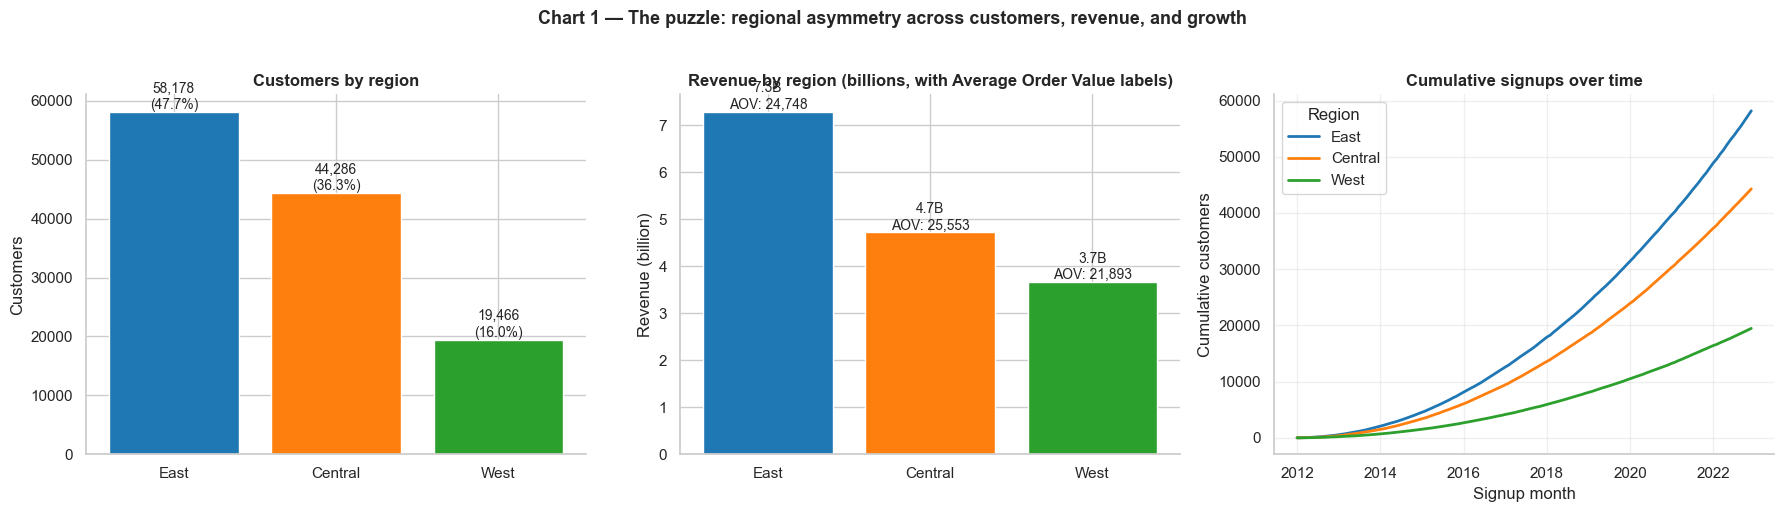

In [13]:
# Three-panel: customers by region, revenue by region, cumulative signups
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Panel A: customer counts ---
cust_by_region = cust_geo["region"].value_counts().reindex(REGION_ORDER)
colors = [REGION_COLORS[r] for r in cust_by_region.index]
bars = axes[0].bar(cust_by_region.index, cust_by_region.values, color=colors)
axes[0].set_title("Customers by region", weight="bold")
axes[0].set_ylabel("Customers")
axes[0].ticklabel_format(style="plain", axis="y")
total = cust_by_region.sum()
for bar, v in zip(bars, cust_by_region.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, v, f"{v:,}\n({v/total:.1%})",
                 ha="center", va="bottom", fontsize=10)

# --- Panel B: revenue + AOV by region ---
rev_by_region = oi_full.groupby("region").agg(
    orders=("order_id", "nunique"),
    revenue=("net", "sum"),
).reindex(REGION_ORDER)
rev_by_region["aov"] = rev_by_region["revenue"] / rev_by_region["orders"]

colors = [REGION_COLORS[r] for r in rev_by_region.index]
bars = axes[1].bar(rev_by_region.index, rev_by_region["revenue"] / 1e9, color=colors)
axes[1].set_title("Revenue by region (billions, with Average Order Value labels)", weight="bold")
axes[1].set_ylabel("Revenue (billion)")
for bar, rev, aov in zip(bars, rev_by_region["revenue"], rev_by_region["aov"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, rev/1e9,
                 f"{rev/1e9:.1f}B\nAOV: {aov:,.0f}",
                 ha="center", va="bottom", fontsize=10)

# --- Panel C: cumulative signups over time ---
signups = (
    cust_geo.dropna(subset=["region"])
    .assign(month=cust_geo["signup_date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["month", "region"]).size().unstack(fill_value=0)
    .reindex(columns=REGION_ORDER)
    .sort_index()
    .cumsum()
)
for region in signups.columns:
    axes[2].plot(signups.index, signups[region], label=region,
                 color=REGION_COLORS[region], linewidth=2)
axes[2].set_title("Cumulative signups over time", weight="bold")
axes[2].set_ylabel("Cumulative customers")
axes[2].set_xlabel("Signup month")
axes[2].legend(title="Region")
axes[2].grid(alpha=0.3)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Chart 1 — The puzzle: regional asymmetry across customers, revenue, and growth",
             fontsize=13, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

**What the chart shows:**

- **East dominates customers** (47%) and revenue (~₫7.3B). **West has the smallest of everything** — 16% of customers and ~₫3.7B revenue.
- The AOV labels reveal the hidden second story: **East ₫24.7K, Central ₫25.5K, West only ₫21.9K**. West isn't just smaller — each West order is also ~14% smaller in value.
- The growth lines confirm it's structural: West's curve is shallower than East's. The gap is *widening*, not closing.

**Conclusion**: West underperforms on three dimensions at once. We have done checks showed customer demographics (age, channel mix) are essentially identical across regions, so it's not *who* the customers are. So we will investigate on where exactly does the Average Orders Value (AOV) gap live?

### 2.1.2 Where does the AOV gap come from?


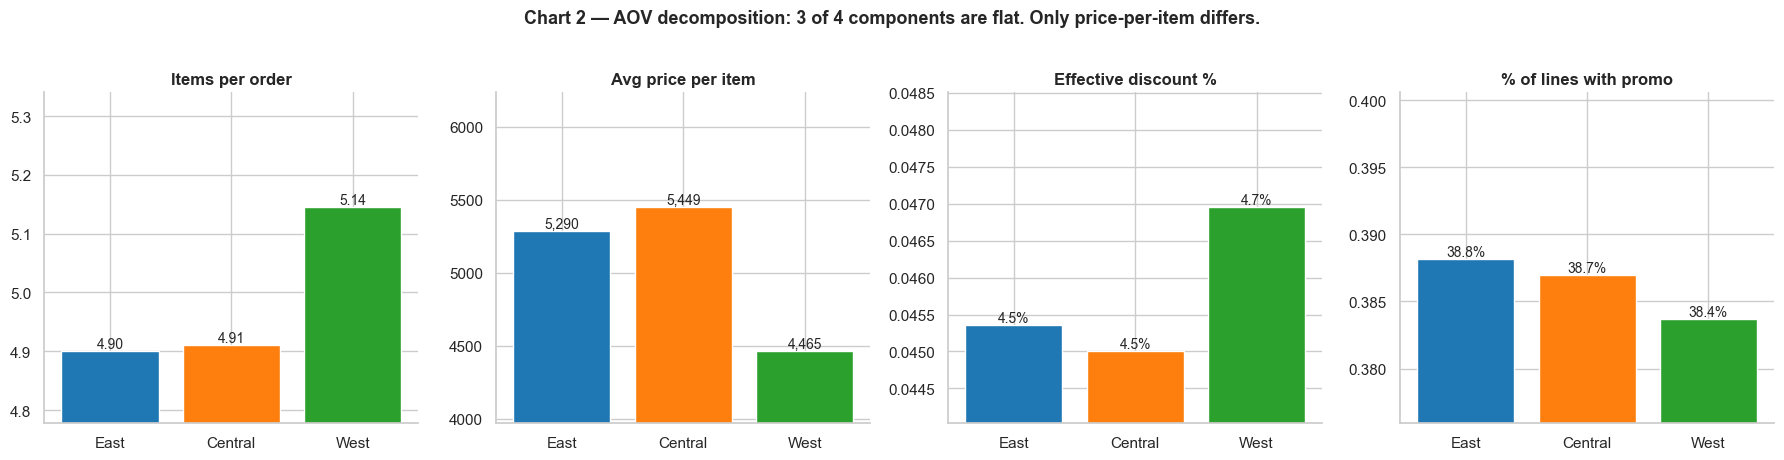

,orders,items_per_order,price_per_item,discount_rate,promo_share
region,,,,,
East,"294,612",4.90,"5,290.21",4.54%,38.82%
Central,"184,691",4.91,"5,448.82",4.50%,38.70%
West,"167,642",5.14,"4,465.15",4.70%,38.37%


In [14]:
# AOV = items_per_order × price_per_item × (1 - discount_rate)
# Decompose each component by region
decomp = (
    oi_full.groupby("region")
    .agg(
        orders=("order_id", "nunique"),
        items=("quantity", "sum"),
        gross=("gross", "sum"),
        discount=("discount", "sum"),
        promo_lines=("has_promo", "sum"),
        total_lines=("order_id", "size"),
    )
    .assign(
        items_per_order=lambda d: d["items"] / d["orders"],
        price_per_item=lambda d: d["gross"] / d["items"],
        discount_rate=lambda d: d["discount"] / d["gross"],
        promo_share=lambda d: d["promo_lines"] / d["total_lines"],
    )
    .reindex(REGION_ORDER)
)

metrics = [
    ("items_per_order", "Items per order",       "{:.2f}"),
    ("price_per_item",  "Avg price per item",    "{:,.0f}"),
    ("discount_rate",   "Effective discount %",  "{:.1%}"),
    ("promo_share",     "% of lines with promo", "{:.1%}"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (col, title, fmt) in zip(axes, metrics):
    vals = decomp[col].values
    colors = [REGION_COLORS[r] for r in decomp.index]
    bars = ax.bar(decomp.index, vals, color=colors)
    ax.set_title(title, weight="bold")
    # tight y-axis around the data so any real difference pops
    lo, hi = vals.min(), vals.max()
    pad = max((hi - lo) * 0.5, hi * 0.02)
    ax.set_ylim(max(0, lo - pad), hi + pad * 1.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v, fmt.format(v),
                ha="center", va="bottom", fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Chart 2 — AOV decomposition: 3 of 4 components are flat. Only price-per-item differs.",
             fontsize=13, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

display(decomp[["orders", "items_per_order", "price_per_item", "discount_rate", "promo_share"]]
        .style.format({
            "orders": "{:,.0f}",
            "items_per_order": "{:.2f}",
            "price_per_item": "{:,.2f}",
            "discount_rate": "{:.2%}",
            "promo_share": "{:.2%}",
        }))

**What the chart shows:**

- **Items per order, discount rate, and promo share are essentially identical** across all three regions (within 0.5 pp). West actually buys *slightly more* items per order (5.14 vs ~4.90).
- The only real gap is **price per item**: ₫5,449 in Central, ₫5,290 in East, but only ₫4,465 in West — about **18% lower**.
- That single component explains the entire 14% AOV gap.

**Conclusion**: West shoppers are not less engaged (their basket size is the highest). They're not getting deeper discounts either. They're just paying less per item. The next chart asks: are they paying less for the *same* products, or buying *different* products?

### 2.1.3 Same products at the same prices — but very different baskets


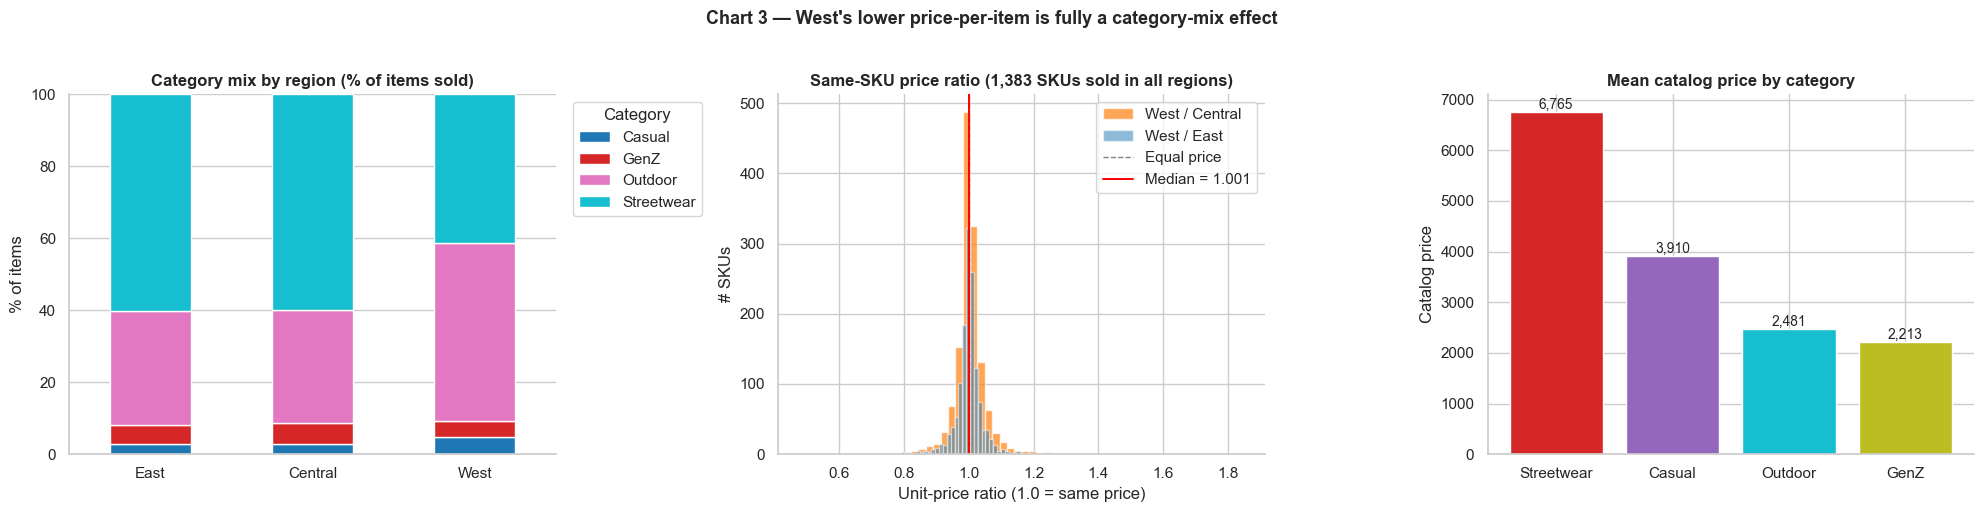

In [15]:
# Three-panel: category mix by region, same-SKU price ratio, mean catalog price by category

# --- Panel A: category mix by region ---
cat_mix = oi_full.groupby(["region", "category"])["quantity"].sum().unstack(fill_value=0)
cat_pct = cat_mix.div(cat_mix.sum(axis=1), axis=0).reindex(REGION_ORDER) * 100

# --- Panel B: same-SKU price ratio (West vs Central + East) ---
sku_price = (
    oi_full.groupby(["product_id", "region"])["unit_price"].mean()
           .unstack("region").dropna()
)
sku_price["W_vs_C"] = sku_price["West"] / sku_price["Central"]
sku_price["W_vs_E"] = sku_price["West"] / sku_price["East"]
median_W_C = sku_price["W_vs_C"].median()

# --- Panel C: mean catalog price by category ---
cat_price = products.groupby("category")["price"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Panel A
cat_pct.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab10", edgecolor="white")
axes[0].set_title("Category mix by region (% of items sold)", weight="bold")
axes[0].set_ylabel("% of items")
axes[0].set_xlabel("")
axes[0].legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[0].set_ylim(0, 100)
axes[0].tick_params(axis="x", rotation=0)

# Panel B
axes[1].hist(sku_price["W_vs_C"], bins=60, color="tab:orange", alpha=0.7, label="West / Central")
axes[1].hist(sku_price["W_vs_E"], bins=60, color="tab:blue",   alpha=0.5, label="West / East")
axes[1].axvline(1.0, color="gray", linestyle="--", linewidth=1, label="Equal price")
axes[1].axvline(median_W_C, color="red", linestyle="-", linewidth=1.4,
                label=f"Median = {median_W_C:.3f}")
axes[1].set_title(f"Same-SKU price ratio ({len(sku_price):,} SKUs sold in all regions)", weight="bold")
axes[1].set_xlabel("Unit-price ratio (1.0 = same price)")
axes[1].set_ylabel("# SKUs")
axes[1].legend()

# Panel C
cat_colors = ["tab:red", "tab:purple", "tab:cyan", "tab:olive"][:len(cat_price)]
bars = axes[2].bar(cat_price.index, cat_price.values, color=cat_colors)
axes[2].set_title("Mean catalog price by category", weight="bold")
axes[2].set_ylabel("Catalog price")
axes[2].ticklabel_format(style="plain", axis="y")
for bar, v in zip(bars, cat_price.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v, f"{v:,.0f}",
                 ha="center", va="bottom", fontsize=10)

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.suptitle("Chart 3 — West's lower price-per-item is fully a category-mix effect",
             fontsize=13, weight="bold", y=1.02)
plt.tight_layout()
plt.show()

**What the chart shows:**

- **Panel A (mix):** East and Central baskets are 60% **Streetwear**. West's basket is only 41% Streetwear — replaced by **Outdoor** (49%, vs ~31% elsewhere).
- **Panel B (pricing):** for the 1,383 SKUs sold in all regions, the median West/Central unit-price ratio is **1.001** — essentially identical. **Pricing is fully ruled out**: same products cost the same everywhere.
- **Panel C (catalog):** Streetwear (East/Central's favorite) averages ₫6,765 per item. **Outdoor (West's favorite) averages only ₫2,481** — about 63% cheaper as a category.

**Mechanism locked in**: West's basket is tilted toward an intrinsically cheaper product line. Same prices, different products. This is not a discount problem, not a pricing problem, not an engagement problem — it's a product-mix preference.

### 2.1 Conclusion — West region diagnosis

**Findings:**

1. **West has 16% of customers and 14% lower AOV** (₫21,893 vs ₫24,748 East, ₫25,553 Central).
2. **The AOV gap is entirely price-per-item** (West ₫4,465 vs Central ₫5,449, -18%). Items per order, discount rate, and promo share are flat across regions.
3. **Same SKUs cost the same everywhere** (median W/C ratio = 1.001 across 1,383 SKUs). It's not a pricing problem.
4. **It's a category-mix problem.** West is 49% Outdoor (avg ₫2,481/item); East is 60% Streetwear (avg ₫6,765/item).
5. **West is actually the most engaged region**, with 5.14 items/order vs 4.90 elsewhere.



---

## 2.2 Khuyến mãi đang đổi lợi nhuận lấy doanh thu

Khi tách doanh thu theo trạng thái khuyến mãi, bức tranh không đẹp như mong đợi. Nhóm có promo tạo ra ~₫4.686B doanh thu (gần **29.9%** tổng doanh thu) nhưng ghi nhận **−₫677.6M** lợi nhuận gộp. Trong khi đó, nhóm không khuyến mãi tạo ra ₫10.995B doanh thu và ₫2.195B lợi nhuận gộp. Tỷ trọng cũng cho thấy vấn đề: promo chiếm tới **38.7%** order lines nhưng chỉ đóng góp **29.9%** doanh thu.

**Giả thuyết.** Khuyến mãi hiện tại đang được dùng quá rộng hoặc đặt trên những sản phẩm không còn đủ biên lợi nhuận, khiến doanh số tăng nhưng chất lượng doanh thu giảm.


,has_promo,order_lines,unique_products,revenue,avg_line_revenue,gross_profit,promo_status,revenue_per_product,gross_profit_per_product,gross_margin_pct
0,0,438344,1539,"10,995,039,052.90","25,083.13","2,195,015,385.58",No promotion,"7,144,274.89","1,426,260.81",0.20
1,1,276309,1495,"4,685,830,212.53","16,958.66","-677,596,639.27",Promotion,"3,134,334.59","-453,241.90",-0.14


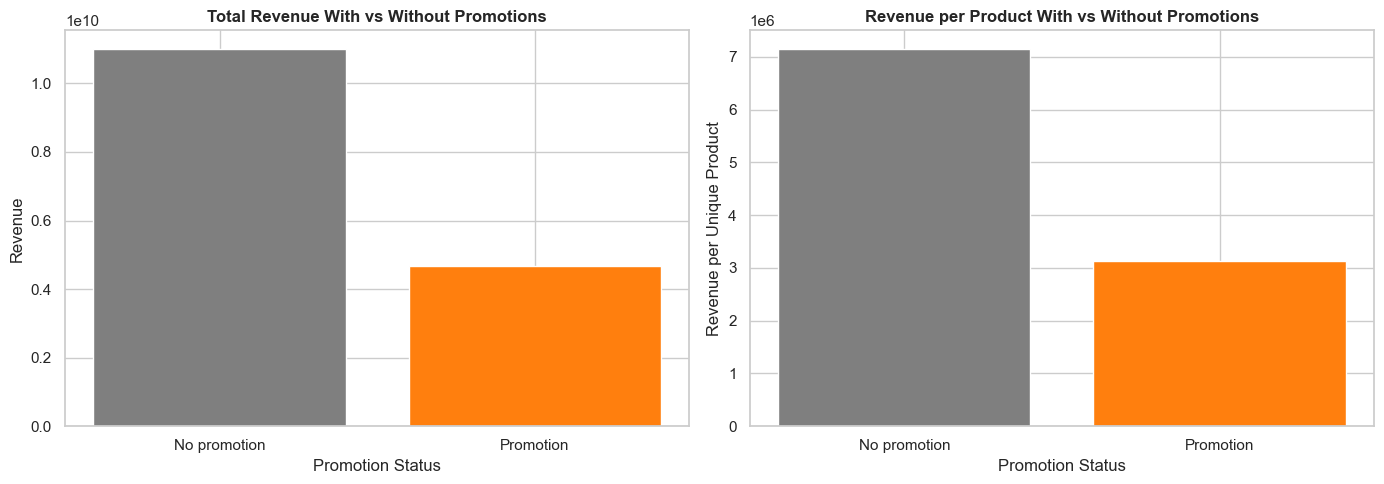

In [16]:
promo_summary = fact_orders.groupby("has_promo").agg(
    order_lines=("product_id", "count"),
    unique_products=("product_id", "nunique"),
    revenue=("line_revenue", "sum"),
    avg_line_revenue=("line_revenue", "mean"),
    gross_profit=("gross_profit", "sum"),
).reset_index()
promo_summary["promo_status"] = promo_summary["has_promo"].map({0: "No promotion", 1: "Promotion"})

# Normalizing by unique product makes the comparison fairer when one group covers many more SKUs.
promo_summary["revenue_per_product"] = promo_summary["revenue"] / promo_summary["unique_products"]
promo_summary["gross_profit_per_product"] = promo_summary["gross_profit"] / promo_summary["unique_products"]
promo_summary["gross_margin_pct"] = promo_summary["gross_profit"] / promo_summary["revenue"]
display(promo_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(promo_summary["promo_status"], promo_summary["revenue"], color=["tab:gray", "tab:orange"])
axes[0].set_title("Total Revenue With vs Without Promotions", weight="bold")
axes[0].set_xlabel("Promotion Status")
axes[0].set_ylabel("Revenue")

axes[1].bar(promo_summary["promo_status"], promo_summary["revenue_per_product"], color=["tab:gray", "tab:orange"])
axes[1].set_title("Revenue per Product With vs Without Promotions", weight="bold")
axes[1].set_xlabel("Promotion Status")
axes[1].set_ylabel("Revenue per Unique Product")

plt.tight_layout()
plt.show()

,promo_type,order_lines,revenue,avg_discount,gross_profit,gross_margin_pct
1,percentage,255359,"4,314,083,021.23","2,916.99","-442,339,347.94",-0.10
0,fixed,20950,"371,747,191.30",225.61,"-235,257,291.33",-0.63


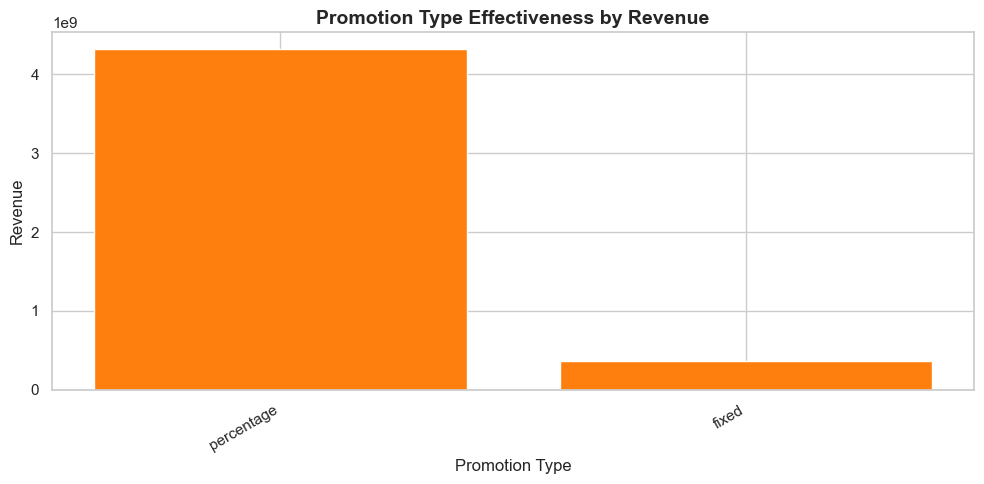

In [17]:
promo_orders = fact_orders.merge(promotions[["promo_id", "promo_type", "discount_value", "promo_channel"]], on="promo_id", how="left")
promo_type_summary = (
    promo_orders[promo_orders["has_promo"] == 1]
    .groupby("promo_type", dropna=False)
    .agg(
        order_lines=("product_id", "count"),
        revenue=("line_revenue", "sum"),
        avg_discount=("discount_amount", "mean"),
        gross_profit=("gross_profit", "sum"),
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)
promo_type_summary["gross_margin_pct"] = promo_type_summary["gross_profit"] / promo_type_summary["revenue"]
display(promo_type_summary)

plt.figure(figsize=(10, 5))
plt.bar(promo_type_summary["promo_type"].astype(str), promo_type_summary["revenue"], color="tab:orange")
finish_plot("Promotion Type Effectiveness by Revenue", "Promotion Type", "Revenue", legend=False, rotation=30)

**Bằng chứng chính.**

- Biên lợi nhuận gộp của nhóm có promo ~ **−14.5%**; nhóm không promo ~ **20.0%**.
- Promo `percentage` tạo ₫4.314B doanh thu nhưng vẫn margin âm.
- Promo `fixed` chỉ tạo ₫371.7M doanh thu nhưng có biên xấu nhất, ~ **−63.3%**.

**Kết luận.** Doanh nghiệp đang đánh đổi lợi nhuận để lấy doanh thu, và mức đánh đổi hiện tại là quá đắt. Nếu tiếp tục scale theo cách này, mỗi đợt đẩy doanh số sẽ làm doanh thu tăng nhưng thu về lợi nhuận âm.

**Tổng thể:** Cần quản trị khuyến mãi như một quyết định lợi nhuận, không chỉ là công cụ kéo doanh số.


---

## 2.3 Doanh thu mùa cao điểm đang bị chặn bởi năng lực tồn kho

Phân tích chuỗi doanh thu theo ngày cho thấy mùa cao điểm rất rõ. Giai đoạn **tháng 4 – tháng 6** tạo ra ~₫2B doanh thu mỗi tháng (≈₫6.5M/ngày) — cao gấp **2.32×** so với tháng 10 – tháng 12 (~₫2.81M/ngày). Điểm đáng chú ý: khi doanh thu đi lên, tín hiệu tồn kho lại xấu đi thay vì cải thiện — `stockout_days` có tương quan **dương** với doanh thu (corr = 0.589) và `fill_rate` có tương quan **âm** (corr = −0.363).

**Giả thuyết.** Đây không phải "thiếu hàng → doanh thu cao". Cách hiểu hợp lý hơn: khi nhu cầu tăng mạnh, hệ thống bổ sung hàng không theo kịp, nên doanh thu thực tế bắt đầu bị giới hạn.


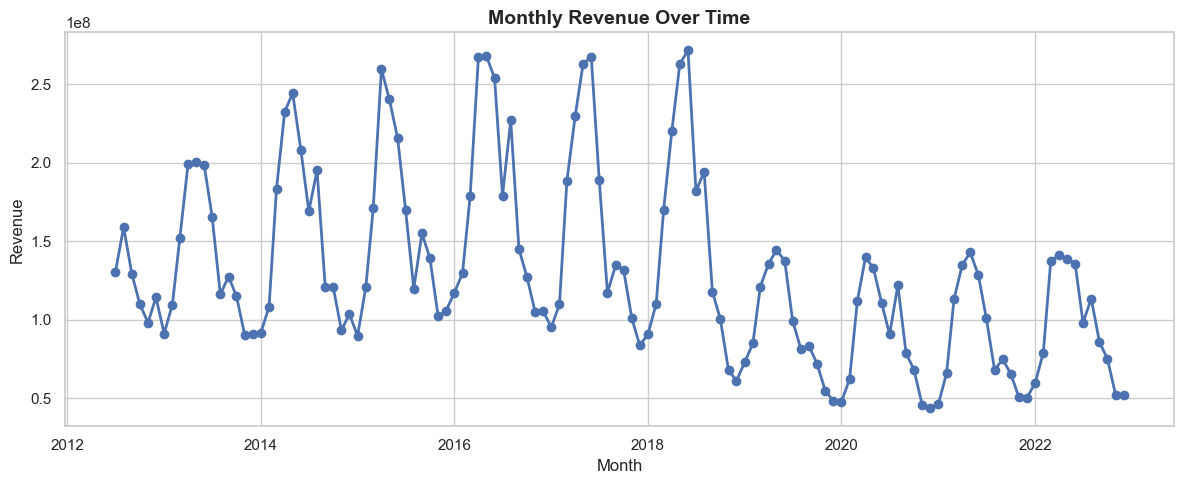

In [18]:
monthly_revenue = daily_metrics.dropna(subset=["date"]).set_index("date")["revenue"].resample("MS").sum().reset_index()

plt.figure(figsize=PLOT_SIZE)
plt.plot(monthly_revenue["date"], monthly_revenue["revenue"], marker="o", linewidth=2)
finish_plot("Monthly Revenue Over Time", "Month", "Revenue", legend=False)

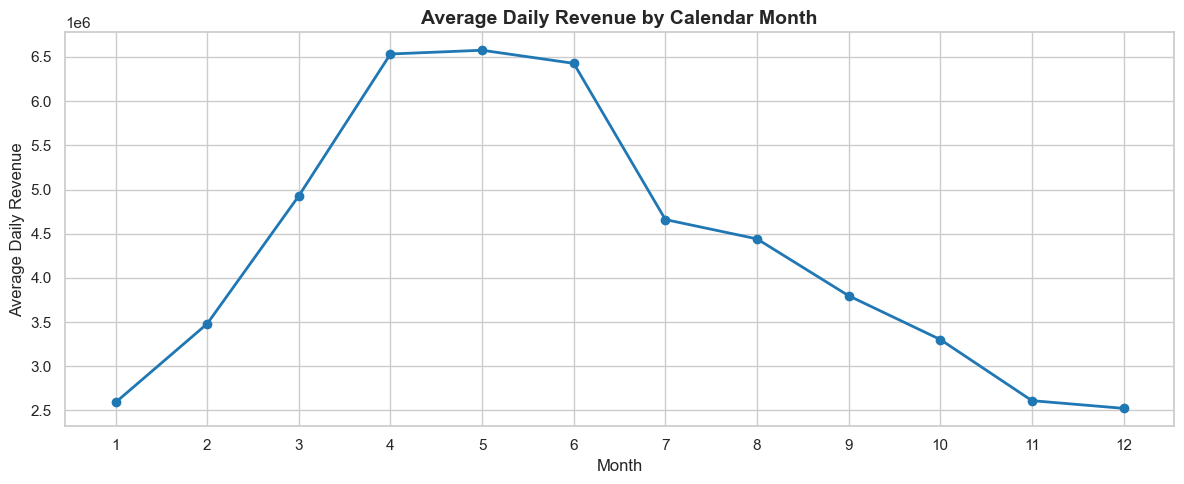

,month,avg_revenue,total_revenue
0,1,"2,591,154.60","803,257,927.41"
1,2,"3,480,800.78","981,585,819.44"
2,3,"4,928,185.47","1,527,737,496.68"
3,4,"6,532,951.88","1,959,885,564.63"
4,5,"6,575,416.35","2,038,379,068.34"
5,6,"6,427,108.65","1,928,132,595.68"
6,7,"4,659,789.37","1,575,008,808.66"
7,8,"4,441,193.49","1,514,446,980.09"
8,9,"3,797,825.60","1,253,282,448.52"
9,10,"3,302,725.22","1,126,229,299.76"


In [19]:
seasonality = daily_metrics.dropna(subset=["date", "revenue"]).copy()
seasonality["month"] = seasonality["date"].dt.month
monthly_pattern = seasonality.groupby("month").agg(avg_revenue=("revenue", "mean"), total_revenue=("revenue", "sum")).reset_index()

plt.figure(figsize=PLOT_SIZE)
plt.plot(monthly_pattern["month"], monthly_pattern["avg_revenue"], marker="o", linewidth=2, color="tab:blue")
plt.xticks(range(1, 13))
finish_plot("Average Daily Revenue by Calendar Month", "Month", "Average Daily Revenue", legend=False)

display(monthly_pattern)

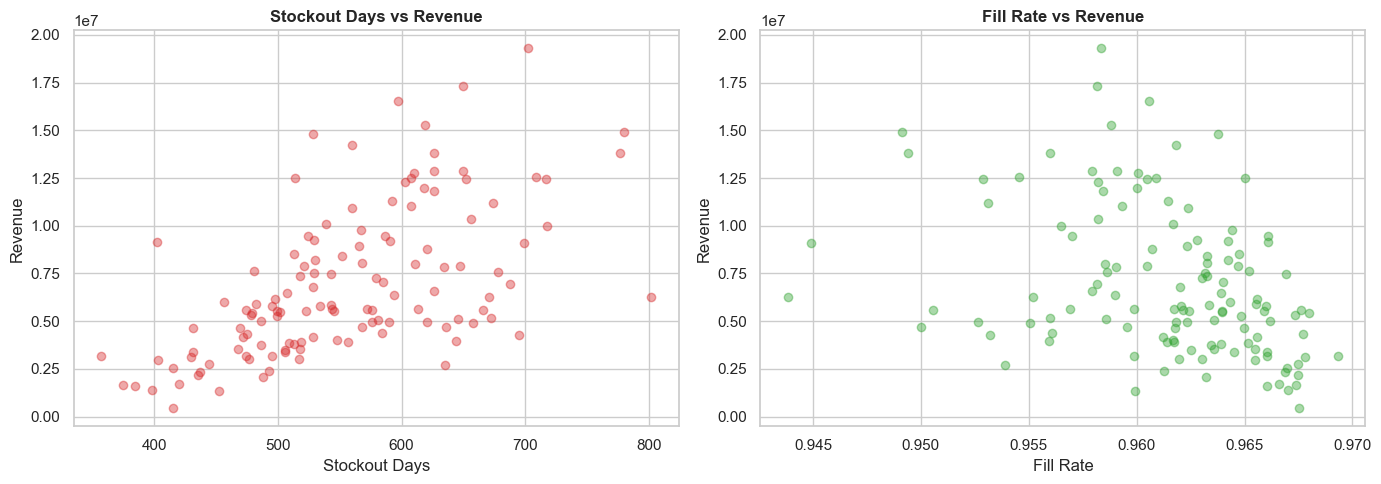

Correlation stockout_days vs revenue: 0.589
Correlation fill_rate vs revenue: -0.363


In [20]:
inv_revenue = daily_metrics.dropna(subset=["revenue", "stockout_days", "fill_rate"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(inv_revenue["stockout_days"], inv_revenue["revenue"], alpha=0.4, color="tab:red")
axes[0].set_title("Stockout Days vs Revenue", weight="bold")
axes[0].set_xlabel("Stockout Days")
axes[0].set_ylabel("Revenue")

axes[1].scatter(inv_revenue["fill_rate"], inv_revenue["revenue"], alpha=0.4, color="tab:green")
axes[1].set_title("Fill Rate vs Revenue", weight="bold")
axes[1].set_xlabel("Fill Rate")
axes[1].set_ylabel("Revenue")
plt.tight_layout()
plt.show()

print(f"Correlation stockout_days vs revenue: {inv_revenue['stockout_days'].corr(inv_revenue['revenue']):.3f}")
print(f"Correlation fill_rate vs revenue: {inv_revenue['fill_rate'].corr(inv_revenue['revenue']):.3f}")

,sessions_7d_vs_next_7d_revenue,stockout_days_7d_vs_next_7d_revenue
0,0.37,0.51


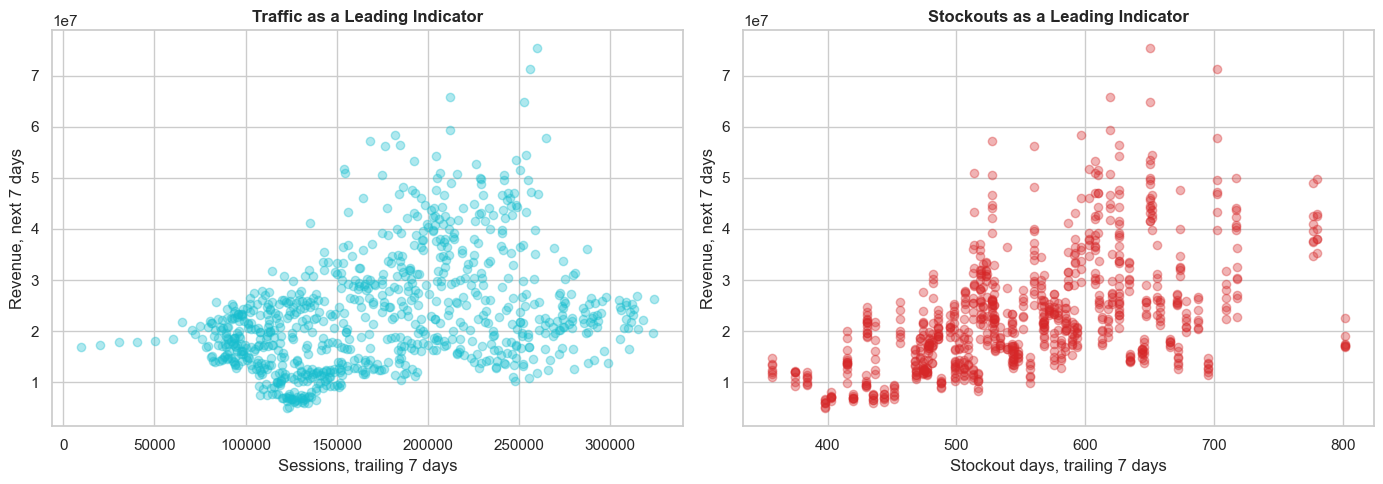

In [ ]:
lead_df = daily_metrics.sort_values("date").copy()
lead_df["revenue_next_7d"] = lead_df["revenue"].rolling(7, min_periods=1).sum().shift(-7)
lead_df["sessions_7d"] = lead_df["sessions"].rolling(7, min_periods=1).sum()
lead_df["stockout_days_7d"] = lead_df["stockout_days"].rolling(7, min_periods=1).sum()

leading_corr = {
    "sessions_7d_vs_next_7d_revenue": lead_df["sessions_7d"].corr(lead_df["revenue_next_7d"]),
    "stockout_days_7d_vs_next_7d_revenue": lead_df["stockout_days_7d"].corr(lead_df["revenue_next_7d"]),
}
display(pd.DataFrame([leading_corr]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = lead_df.dropna(subset=["revenue_next_7d", "sessions_7d", "stockout_days_7d"])
axes[0].scatter(plot_df["sessions_7d"], plot_df["revenue_next_7d"], alpha=0.35, color="tab:cyan")
axes[0].set_title("Traffic as a Leading Indicator", weight="bold")
axes[0].set_xlabel("Sessions, trailing 7 days")
axes[0].set_ylabel("Revenue, next 7 days")

axes[1].scatter(plot_df["stockout_days_7d"], plot_df["revenue_next_7d"], alpha=0.35, color="tab:red")
axes[1].set_title("Stockouts as a Leading Indicator", weight="bold")
axes[1].set_xlabel("Stockout days, trailing 7 days")
axes[1].set_ylabel("Revenue, next 7 days")
plt.tight_layout()
plt.show()

**Bằng chứng chính.**

- Mùa cao điểm tập trung rõ ở tháng 4 – tháng 6.
- Những ngày doanh thu cao thường cũng là những ngày có nhiều `stockout_days` hơn.
- Chỉ báo dẫn `stockout_days_7d` có tương quan **0.51** với `revenue_next_7d`, cho thấy áp lực tồn kho không chỉ xảy ra cùng lúc mà còn kéo dài sang các ngày sau.

**Kết luận.** Doanh nghiệp đang bán tốt nhất đúng vào lúc kho bị thiếu hàng. Tăng trưởng hiện tại có dấu hiệu bị giới hạn bởi khả năng đáp ứng hàng, không chỉ bởi nhu cầu thị trường.

**Dự báo.** Nếu pattern hiện tại lặp lại, doanh thu sẽ tăng trở lại từ tháng 3 – tháng 6; rủi ro stockout cũng sẽ tăng. Mùa cao điểm năm sau nhiều khả năng vẫn bị giới hạn doanh thu nếu kế hoạch tồn kho không đi trước nhu cầu.

**Tổng thể:** Vấn đề chính nằm ở khả năng đáp ứng hàng hóa. Nếu xử lý đúng các điểm thiếu hàng, doanh nghiệp có thể thu hồi một phần doanh thu bị mất tương đối nhanh.
